# Yerevan House Price Prediction

In [ ]:
import sys
import subprocess

def install_and_import(package):
    try:
        __import__(package)
    except ImportError:
        print(f"library {package} not found, downloading...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])


required_packages = ["xgboost", "lightgbm", "scikit-learn", "joblib"]

for pkg in required_packages:

    pip_name = "scipy" if pkg == "scikit-learn" else pkg 

    if pkg == "scikit-learn":
        try:
            import sklearn
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    else:
        install_and_import(pkg)

print("everythings installed")


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (cross_validate, cross_val_score, KFold,
                                      RepeatedKFold, RandomizedSearchCV, train_test_split)
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [7]:
df = pd.read_csv('houses_train.csv')
print(df.shape)
df.head()

(5001, 14)


,Unnamed: 0,price,condition,district,max_floor,street,num_rooms,region,area,url,num_bathrooms,building_type,floor,ceiling_height
0,4598,100000.0,newly repaired,Arabkir,6,Kievyan St,3,Yerevan,96.0,http://www.myrealty.am/en/item/26229/3-senyaka...,1,stone,4,3.0
1,5940,52000.0,good,Arabkir,14,Mamikoniants St,3,Yerevan,78.0,http://www.myrealty.am/en/item/32897/3-senyaka...,1,panel,10,2.8
2,2302,52000.0,newly repaired,Qanaqer-Zeytun,9,M. Melikyan St,3,Yerevan,97.0,http://www.myrealty.am/en/item/1459/apartment-...,1,panel,1,2.8
3,5628,130000.0,good,Center,4,Spendiaryan St,3,Yerevan,80.0,http://www.myrealty.am/en/item/2099/3-senyakan...,1,stone,2,3.2
4,760,81600.0,zero condition,Center,9,Ler. Kamsar St,3,Yerevan,107.0,http://www.myrealty.am/en/item/22722/3-senyaka...,1,monolit,9,3.0


## 1. Outlier handling — per-district winsorizing

In [8]:
def winsorize_per_group(series, group, lower=0.01, upper=0.99):
    bounds = pd.DataFrame({'v': series, 'g': group}).groupby('g')['v'].quantile([lower, upper]).unstack()
    lo = group.map(bounds[lower])
    hi = group.map(bounds[upper])
    return series.clip(lower=lo, upper=hi)

df['area'] = winsorize_per_group(df['area'], df['district'])
df['price'] = winsorize_per_group(df['price'], df['district'])

Plotting Price Distribution by District...


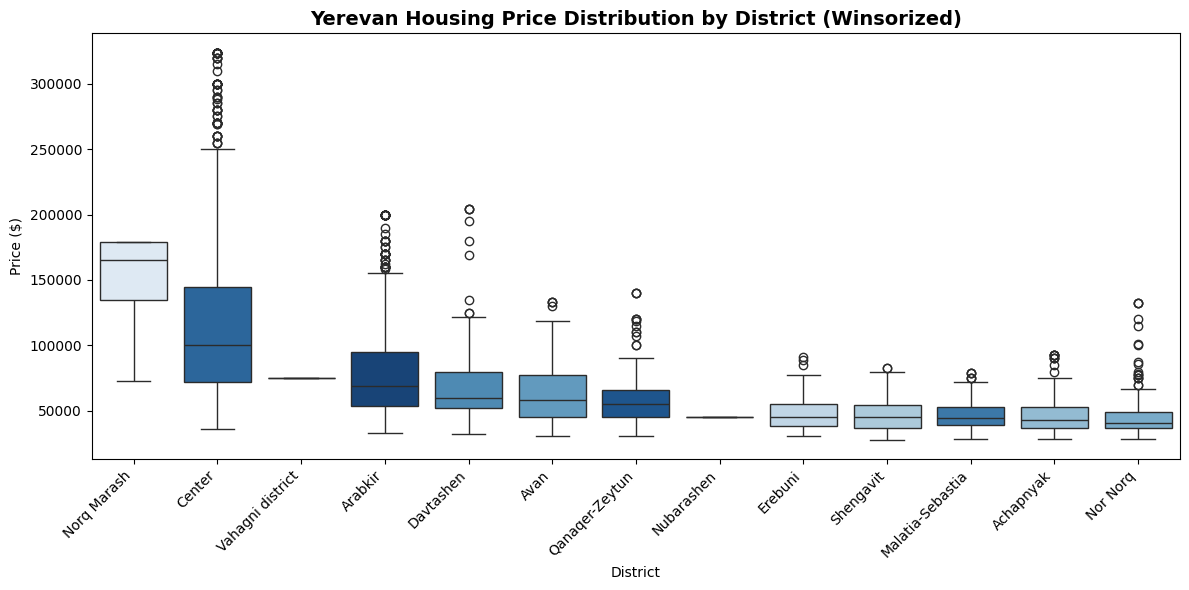

In [9]:
print("Plotting Price Distribution by District...")
plt.figure(figsize=(12, 6))
order = df.groupby('district')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='district', y='price', order=order, hue='district', palette='Blues_r', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Yerevan Housing Price Distribution by District (Winsorized)', fontsize=14, fontweight='bold')
plt.ylabel('Price ($)')
plt.xlabel('District')
plt.tight_layout()
plt.show()

In [10]:
def engineer(df):
    df = df.copy()
    df['room_size'] = df['area'] / df['num_rooms'].replace(0, 1)
    df['floor_ratio'] = df['floor'] / df['max_floor'].replace(0, 1)
    df['is_top_floor'] = (df['floor'] == df['max_floor']).astype(int)
    df['is_ground_floor'] = (df['floor'] <= 1).astype(int)
    df['bath_per_room'] = df['num_bathrooms'] / df['num_rooms'].replace(0, 1)
    df['log_area'] = np.log1p(df['area'])
    df['ceiling_area'] = df['ceiling_height'] * df['area']
    df['district_building'] = df['district'].astype(str) + '_' + df['building_type'].astype(str)
    return df

df = engineer(df)
print("floor == 0 (ground?):", (df['floor'] == 0).sum())

floor == 0 (ground?): 3


## 2. Feature engineering
added:
- `is_ground_floor` — floor <= 1 (also floor==0)
- `bath_per_room` bathroom/room relations
- `log_area` — (useful for Ridge, target is logged in pipeline)
- `ceiling_area` — ceiling_height × area (most importatant feature by permutation importance)
- `district_building` — district × building_type

In [11]:
X = df.drop(columns=['price', 'url'], errors='ignore')
y = df['price']

num_cols = ['max_floor', 'num_rooms', 'area', 'num_bathrooms', 'floor', 'ceiling_height',
            'room_size', 'floor_ratio', 'is_top_floor', 'is_ground_floor', 'bath_per_room',
            'log_area', 'ceiling_area']
cat_low_card = ['condition', 'district', 'region', 'building_type', 'district_building']
cat_high_card = ['street']  # Target Encoded (350+ unique values)

In [12]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imp', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), num_cols),

    ('cat_low', Pipeline(steps=[
        ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_low_card),

    ('cat_high', Pipeline(steps=[
        ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
        ('target_enc', TargetEncoder(target_type='continuous', random_state=42))
    ]), cat_high_card)
])

In [13]:
X.columns.to_list()

['Unnamed: 0',
 'condition',
 'district',
 'max_floor',
 'street',
 'num_rooms',
 'region',
 'area',
 'num_bathrooms',
 'building_type',
 'floor',
 'ceiling_height',
 'room_size',
 'floor_ratio',
 'is_top_floor',
 'is_ground_floor',
 'bath_per_room',
 'log_area',
 'ceiling_area',
 'district_building']

## 3. Model comparison — R², RMSE, MAE

In [14]:
models_to_test = {
    'Ridge': RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 100.0, 500.0]),
    'RandomForest': RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=250, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1, verbosity=-1),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'r2': 'r2', 'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error'}

results = {}
for name, model in models_to_test.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    wrapped = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    cv_res = cross_validate(wrapped, X, y, cv=kf, scoring=scoring, n_jobs=-1)
    results[name] = {
        'R2': cv_res['test_r2'].mean(),
        'R2_std': cv_res['test_r2'].std(),
        'MAE': -cv_res['test_mae'].mean(),
        'RMSE': -cv_res['test_rmse'].mean(),
    }
    print(f"{name:12s} R2={results[name]['R2']:.4f} (±{results[name]['R2_std']:.4f})  "
          f"MAE=${results[name]['MAE']:,.0f}  RMSE=${results[name]['RMSE']:,.0f}")

pd.DataFrame(results).T

Ridge        R2=0.8023 (±0.0071)  MAE=$14,729  RMSE=$22,573
RandomForest R2=0.8208 (±0.0077)  MAE=$13,861  RMSE=$21,486
XGBoost      R2=0.8261 (±0.0125)  MAE=$13,708  RMSE=$21,156
LightGBM     R2=0.8261 (±0.0129)  MAE=$13,801  RMSE=$21,148


,R2,R2_std,MAE,RMSE
Ridge,0.802347,0.007140,14728.590318,22572.869825
RandomForest,0.820819,0.007705,13861.428542,21486.381638
XGBoost,0.826054,0.012519,13708.336054,21155.737762
LightGBM,0.826087,0.012918,13801.260086,21148.218232


## 4. Stability check — RepeatedKFold
just one 5-fold split has ±0.019 std (a noise)։ We're checking the best models with RepeatedKFold-ով (5×3), to make sure the difference in scores is real and not some split magic.

In [15]:
best_two = sorted(results.items(), key=lambda kv: kv[1]['R2'], reverse=True)[:2]
print("Top-2 by mean R2:", [n for n, _ in best_two])

rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
model_lookup = {
    'RandomForest': RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=250, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1, verbosity=-1),
}
for name, _ in best_two:
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model_lookup[name])])
    wrapped = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    scores = cross_val_score(wrapped, X, y, cv=rkf, scoring='r2', n_jobs=-1)
    print(f"[RepeatedKFold] {name}: R2={scores.mean():.4f} (±{scores.std():.4f})")

Top-2 by mean R2: ['LightGBM', 'XGBoost']
[RepeatedKFold] LightGBM: R2=0.8271 (±0.0140)
[RepeatedKFold] XGBoost: R2=0.8289 (±0.0128)


## 5. Light hyperparameter tuning
instead of fixed hyperparameters - quick `RandomizedSearchCV` on LightGBM(~5000 rows takes just some seconds)

In [16]:
lgbm_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                            ('regressor', LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1))])
wrapped = TransformedTargetRegressor(regressor=lgbm_pipe, func=np.log1p, inverse_func=np.expm1)

param_dist = {
    'regressor__regressor__n_estimators': [200, 300, 400, 600],
    'regressor__regressor__learning_rate': [0.03, 0.05, 0.08, 0.1],
    'regressor__regressor__max_depth': [4, 6, 8, -1],
    'regressor__regressor__num_leaves': [15, 31, 63],
}
search = RandomizedSearchCV(wrapped, param_dist, n_iter=10, cv=3, scoring='r2',
                             random_state=42, n_jobs=-1)
search.fit(X, y)
print("Best params:", search.best_params_)
print("Best CV R2:", search.best_score_)
best_lgbm_params = {k.split('__')[-1]: v for k, v in search.best_params_.items()}

Best params: {'regressor__regressor__num_leaves': 31, 'regressor__regressor__n_estimators': 300, 'regressor__regressor__max_depth': -1, 'regressor__regressor__learning_rate': 0.08}
Best CV R2: 0.828051117554245


## 6. Final model — blend (RandomForest + XGBoost + tuned LightGBM)
RF (0.82) and XGB (0.826) are similar — take RF + XGB + tuned LightGBM predictions with `VotingRegressor`. It's usually more stable than a single model alone.

In [17]:
voting = VotingRegressor(estimators=[
    ('rf', RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(n_estimators=250, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)),
    ('lgbm', LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1, **best_lgbm_params)),
])

full_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', voting)])
final_model = TransformedTargetRegressor(regressor=full_pipe, func=np.log1p, inverse_func=np.expm1)

blend_scores = cross_val_score(final_model, X, y, cv=kf, scoring='r2', n_jobs=-1)
print(f"Blend: R2={blend_scores.mean():.4f} (±{blend_scores.std():.4f})")

Blend: R2=0.8313 (±0.0118)


## 7. Holdout check + Permutation Importance
checking if `condition`/`building_type`-like features help or are they just a noise

In [18]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
final_model.fit(X_tr, y_tr)
pred = final_model.predict(X_te)

print(f"Holdout R2:   {r2_score(y_te, pred):.4f}")
print(f"Holdout MAE:  ${mean_absolute_error(y_te, pred):,.0f}")
print(f"Holdout RMSE: ${mean_squared_error(y_te, pred) ** 0.5:,.0f}")

perm = permutation_importance(final_model, X_te, y_te, n_repeats=5, random_state=42, n_jobs=-1)
importance = pd.Series(perm.importances_mean, index=X_te.columns).sort_values(ascending=False)
print("\nPermutation importance (top features):")
print(importance)

c:\Users\aleks\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\aleks\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Holdout R2:   0.8323
Holdout MAE:  $13,628
Holdout RMSE: $21,008

Permutation importance (top features):
street               3.568395e-01
ceiling_area         3.064336e-01
area                 7.965750e-02
district             7.801545e-02
condition            5.353158e-02
max_floor            1.889213e-02
building_type        1.475851e-02
floor_ratio          1.048712e-02
floor                9.154874e-03
room_size            8.521964e-03
log_area             5.379188e-03
district_building    2.824602e-03
num_bathrooms        8.551158e-04
ceiling_height       8.212718e-04
is_ground_floor      2.114307e-04
num_rooms            1.188537e-04
Unnamed: 0          -2.220446e-17
region              -4.440892e-17
is_top_floor        -6.359869e-05
bath_per_room       -4.121783e-04
dtype: float64


## 8. Fit on FULL training data and save model
The model is saved in a `.pkl` file so training is no more needed after that.


In [19]:
final_model.fit(X, y)

joblib.dump(final_model, 'houses_price_model.pkl')
print("Model is saved: houses_price_model.pkl")

Model is saved: houses_price_model.pkl


## 9. Inference — loading new test data and getting predictions

This is the part that lets one load a new CSV file with apartments
(same raw columns as `houses_train.csv`, but without the `price` column) and get price
predictions using the already-trained model saved above (`houses_price_model.pkl`).

No retraining is required — this cell only loads the saved pipeline.


In [20]:
import joblib
import pandas as pd

# 1. Load the trained pipeline (preprocessing + model are both inside this single object)
loaded_model = joblib.load('houses_price_model.pkl')

# 2. Load new/test data. Change the path below to your file.
#    The file must contain the same raw columns as houses_train.csv
#    (condition, district, max_floor, street, num_rooms, region, area,
#     num_bathrooms, building_type, floor, ceiling_height, ...).
#    It should NOT contain a 'price' column (that's what we're predicting).
test_path = 'houses_test.csv'  # <-- change this to your test file
df_new = pd.read_csv(test_path)

# 3. Apply the SAME feature engineering used for training.
#    Note: winsorizing is intentionally NOT re-applied here, it was only
#    used to clean noisy training data/targets, not for inference.
df_new_fe = engineer(df_new)

X_new = df_new_fe.drop(columns=['price', 'url'], errors='ignore')

# 4. Predict
predictions = loaded_model.predict(X_new)

df_new['predicted_price'] = predictions
df_new.head()


FileNotFoundError: [Errno 2] No such file or directory: 'houses_test.csv'

In [ ]:
# 5. (Optional) save predictions to a CSV file
df_new.to_csv('houses_predictions.csv', index=False)
print("Saved predictions to houses_predictions.csv")
